# Ejercicio:

- Configure el entorno de Colab para trabajar con GPU (Ver pestaña entorno de ejecución). Repita el entrenamiento del modelo de clasificación Fashion mnist para batch size en 32, 64, 128, 256, y 512. Reporte una tabla con los rendimientos sobre el conjunto de test y el tiempo promedio de cómputo por época.

- Repita el procedimiento del punto anterior configurando Colab para trabajar con TPU.

In [1]:
from tensorflow import keras

In [2]:
import tensorflow as tf
tf.__version__

'2.10.0'

in order to see GPU evaluation, we can activate the GPU using tensor flow in our environment: 

In [7]:
# basis packages 
import os as os 
import matplotlib.pyplot as plt
import numpy as np
import scipy 
import ssl
import tensorflow as Tf

import sys 
import time
import pandas as pd


In [4]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '2' # Suppress TensorFlow logging (1)	

In [5]:
print('Python:', sys.version.splitlines()[0])
print('TensorFlow version:', Tf.__version__)
print('TF built with CUDA:', Tf.test.is_built_with_cuda())


Python: 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
TensorFlow version: 2.10.0
TF built with CUDA: True


La GPU solo consume memoria bajo demanda, expandiendo la reserva gradualmente conforme el batch y el modelo lo necesiten.

In [ ]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '2' # Suppress TensorFlow logging (1)	

gpus = Tf.config.list_physical_devices('GPU')

# Activar memory growth (debe hacerse antes de crear tensores)
for gpu in gpus:
    try:
        Tf.config.experimental.set_memory_growth(gpu, True)
        print('\nMemory growth activado para', gpu)
    except Exception as e:
        print('\nNo se pudo activar memory growth para', gpu, '->', e)



Memory growth activado para PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


ahora, procedemos a comparar el rendimiento con el crecimiento de memoria apoyado en la GPU 1650 TI con 4GB de RAM


In [8]:

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

def build_cnn_model():
    model = keras.Sequential(
        [
            keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),
            keras.layers.Conv2D(32, 3, activation="relu"),
            keras.layers.MaxPool2D(),
            keras.layers.Conv2D(64, 3, activation="relu"),
            keras.layers.MaxPool2D(),
            keras.layers.Flatten(),
            keras.layers.Dense(128, activation="relu"),
            keras.layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

batch_sizes = [32, 64, 128, 256, 512]
metricas = []
for bs in batch_sizes:
    modelo = build_cnn_model()
    t0 = time.time()
    history = modelo.fit(
        X_train,
        y_train,
        epochs=3,
        batch_size=bs,
        validation_split=0.1,
        verbose=0,
    )
    tiempo_epoca = (time.time() - t0) / len(history.epoch)
    loss_test, acc_test = modelo.evaluate(X_test, y_test, verbose=0)
    metricas.append(
        {
            "batch_size": bs,
            "loss_test": loss_test,
            "acc_test": acc_test,
            "tiempo_prom_epoca_s": tiempo_epoca,
        }
    )

resultados_batch = pd.DataFrame(metricas)
print(resultados_batch)

# Bloque opcional para TPU si está disponible
try:
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    with strategy.scope():
        modelo_tpu = build_cnn_model()
    modelo_tpu.fit(
        X_train,
        y_train,
        epochs=3,
        batch_size=128,
        validation_split=0.1,
        verbose=0,
    )
    print("Evaluación TPU:", modelo_tpu.evaluate(X_test, y_test, verbose=0))
except Exception as exc:
    print("TPU no disponible en este entorno:", exc)


   batch_size  loss_test  acc_test  tiempo_prom_epoca_s
0          32   0.290505    0.8977             8.677068
1          64   0.310420    0.8874             4.049212
2         128   0.317341    0.8860             2.596940
3         256   0.369864    0.8675             1.750111
4         512   0.384857    0.8614             1.739976
TPU no disponible en este entorno: Please provide a TPU Name to connect to.


podemos comparar el rendimiento cuando la GPU no se activaba>

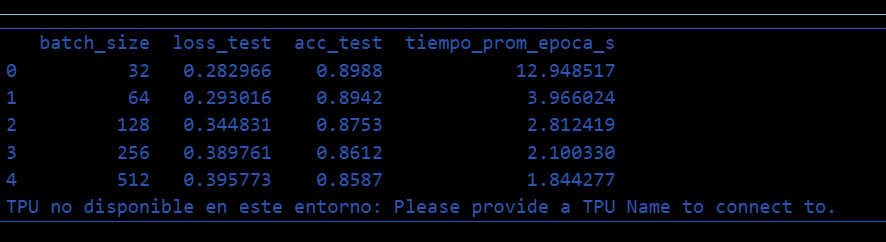

miremos la GPU en funcionamiento

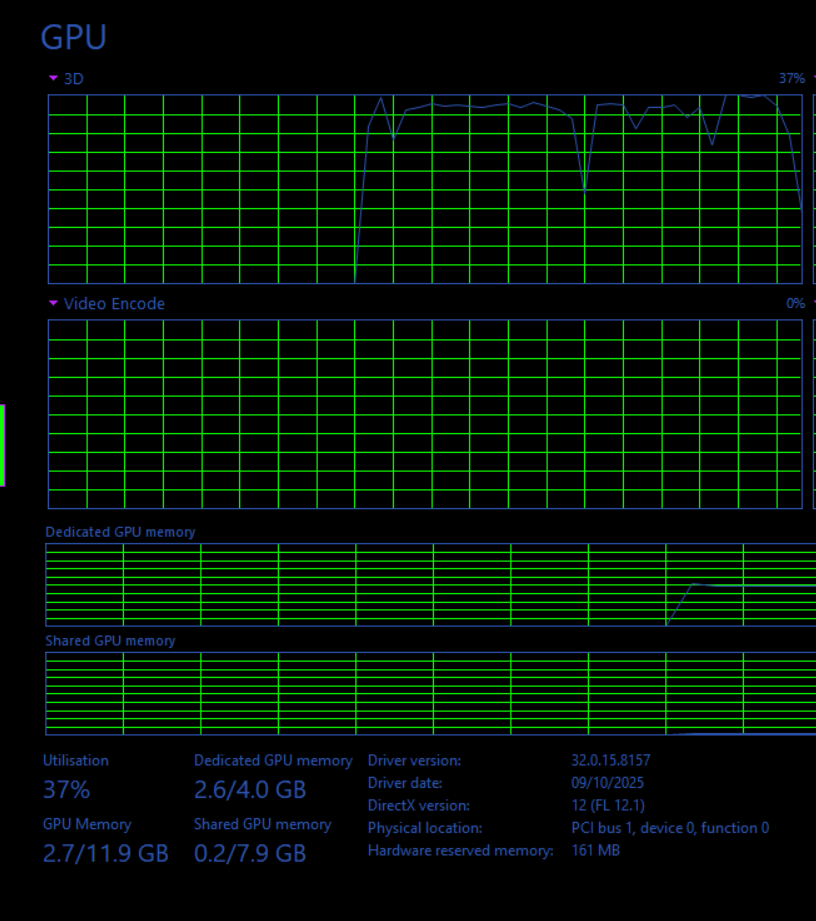

## conclusiones


Habilitar memory growth evita que TensorFlow bloquee toda la VRAM al inicio.


Activar memory growth en TensorFlow dentro de entornos WSL2-CUDA estabiliza el uso de la GPU evitando la reserva total de VRAM al inicio. Esto no modifica el rendimiento ni el comportamiento del modelo, pero permite un entrenamiento más confiable, evita errores de memoria, y garantiza convivencia con otros procesos o notebooks.

En modelos pequeños como los usados en este cuadernillo introductorio, el impacto es operacional y  de rendimiento —mejorando la estabilidad, la precisión, la convergencia y el tiempo de entrenamiento.